## SfM Bathymetry Using SVR Method

This approach will calculate true depth of SfM point cloud using refractive index directly 

### Getting started

To ensure working environment works properly, set to the top level of repository

In [1]:
cd ..

d:\PROGRAM\PYTHON\sfm-bathy-mapper


### Load Packages

Firstly, we need to import packages that will be use in this notebook

In [2]:
import pandas as pd
import numpy as np


from sfmbathy.prep import load_las,tide_calc
from sfmbathy.process import process_small_angle, export_pc
from sfmbathy.validation import validate_bathymetry
from sfmbathy.svm_prediction import svm_depth_prediction,predict_new_sfm_cloud

### Set Input and Output Directory

Set input and output folder (Please be aware with folder name)

In [3]:
input =r"D:\OneDrive\COMPUTER\S2-MASTER\DATA_TESIS\KEPULAUAN_SERIBU\PANGGANG_SVM\PANGGANG_PC_2ppm_REGIS.las"
output = r"D:\OneDrive\COMPUTER\S2-MASTER\DATA_TESIS\KEPULAUAN_SERIBU\PANGGANG_SVM\PANGGANG_PC_SVM_output.las"
train = r"D:\OneDrive\COMPUTER\S2-MASTER\DATA_TESIS\KEPULAUAN_SERIBU\PANGGANG_SVM\PANGGANG_USV_ELLIPSOID.csv"

## Load Data

The input for this process is the point cloud from SfM Photogrammetry in LAS format.
After loading data, it calculated median coordinate in geographic coordinate (EPSG:4326) for predicting tides model.

In [4]:
pc,las,lon_med,lat_med = load_las(input)
mean_elev= np.mean(pc[:,2])
print(f"Mean elevation : {mean_elev:.3f} meters (Elevation relative to WGS84 ellipsoid)")   

CRS EPSG:32748 → EPSG:4326 | Median Lon: 106.598117, Lat: -5.742073
Mean elevation : 17.509 meters (Elevation relative to WGS84 ellipsoid)


## Set Parameter for Tide Modelling

Predicting tide height for determining current water level based on INATIDES model.

In [5]:
tide_dir=r"D:\tide_models" # Directory where the tide model files are stored
model="INATIDES" # Tide model to use for predictions (e.g., "INATIDES", "TPXO", "FES", etc.)
x = lon_med # Longitude of the location for tide predictions
y = lat_med # Latitude of the location for tide predictions
start_time = "2021-08-30 02:56:00" # In UTC time, Start time for tide predictions (in the format "YYYY-MM-DD HH:MM:SS") 
end_time = "2021-08-30 04:21:00" # In UTC time, End time for tide predictions (in the format "YYYY-MM-DD HH:MM:SS") 
freq = "10min" # Frequency of tide predictions (e.g., '1H' for hourly) and '10min' for every 10 minutes

# Refractive index of water
n_water = "default" # You can specify a custom value for the refractive index of water, or use "default" to use the standard value (approximately 1.33)


In [6]:
wl = tide_calc(tide_dir, model, x, y, start_time, end_time, freq) 

Modelling tides with INATIDES
Location Lon: 106.598117, Lat: -5.742073 | time range: 2021-08-30 02:56:00 to 2021-08-30 04:21:00
Representative Water Level: 0.179 m , refer to MSL
Representative Water Level: 19.011 m , refer to Ellipsoid Reference


### Running depth correction based on multi-stereo photogrammetry approach

Correct point cloud depths for the effects of light refraction in water. Using default n_water, which is 1,33. Point cloud would be directly corrected using refractive index.



In [9]:
result = svm_depth_prediction(
        sfm_points=pc,
        usv_points=train,
        wl=wl,
        max_match_dist=2.0,
        test_size=0.25,
        grid_search=True,
        verbose=True,
    )

IndexError: too many indices for array: array is 0-dimensional, but 2 were indexed

### Validation Workflow

Set validation parameter :
1. Validation data
2. Tide datum model
3. Point cloud and validation data coordinate system (EPSG)
4. Depth range for validation
5. Output directory


In [ ]:
valid_dir = train # Validation file (ASCII: X, Y, Z columns) for bathymetry comparison
datum_model = r"D:\tide_models\DATUM\IS_MSL_ELLIPSOID.tif" # tide datum model (GeoTIFF) for converting ellipsoid heights to MSL heights
pc_epsg = 32749  # EPSG code for the point cloud coordinate system 
min_depth = 0  # Filter: minimum depth (m, positive downward)
max_depth = 3# Filter: maximum depth (m). None = no limit
output_validation = r"D:\OneDrive\COMPUTER\S2-MASTER\DATA_TESIS\KEPULAUAN_SERIBU\PANGGANG_SVM\HASIL_UJI"   # Directory to save outputs


SfM BATHYMETRY VALIDATION WORKFLOW

[1/7] Loading data...
Loaded point cloud array: 15484803 points
Loaded validation data: USV5_VALIDATION.txt | 11927 points

[2/7] Transforming to EPSG:4326...

[3/7] Reading datum offsets...
Read datum offsets: 15484803/15484803 points within GeoTIFF bounds
Read datum offsets: 11927/11927 points within GeoTIFF bounds

[4/7] Converting ellipsoid → MSL...
Converted to MSL: 15484803/15484803 points valid
Converted to MSL: 11927/11927 points valid

[5/7] Spatial matching (nearest neighbor)...
Spatial matching: 11927/11927 validation points matched (threshold: 10 m)

[6/7] Filtering by depth range...
Depth range filter (0-3 m): 11218/11927 points retained

[7/7] Calculating metrics and generating plots...

Metrics (11218 points):
  MAE:  0.5508 m
  RMSE: 0.5843 m
  MBE:  0.5463 m
  R²:   0.1616
  Pearson r: 0.9460 (p=0.00e+00)

Generating visualizations...
Saved scatter plot: D:\OneDrive\COMPUTER\S2-MASTER\DATA_TESIS\KARIMUNJAWA\LAS\HASIL_UJI\scatter_reg

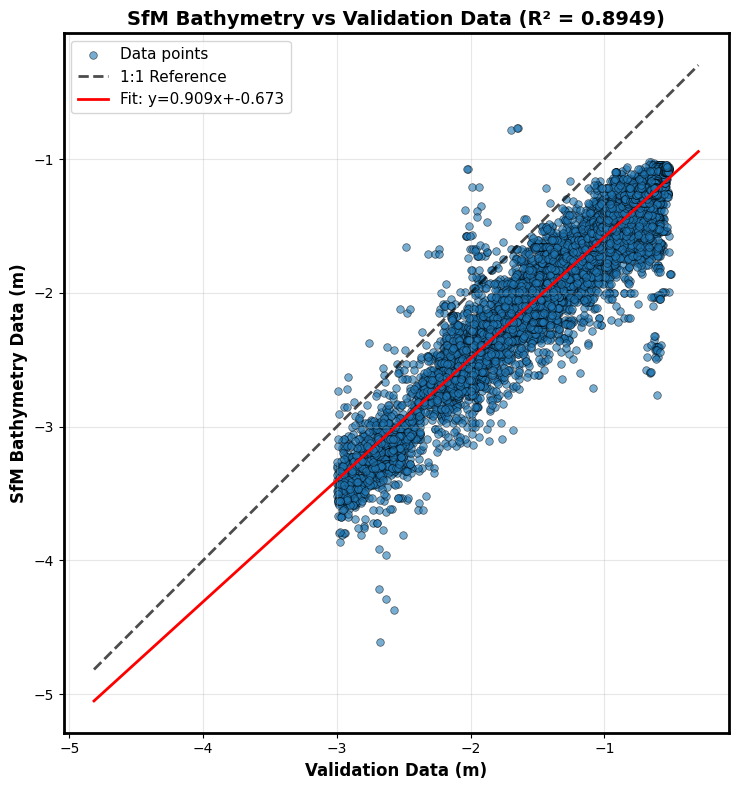

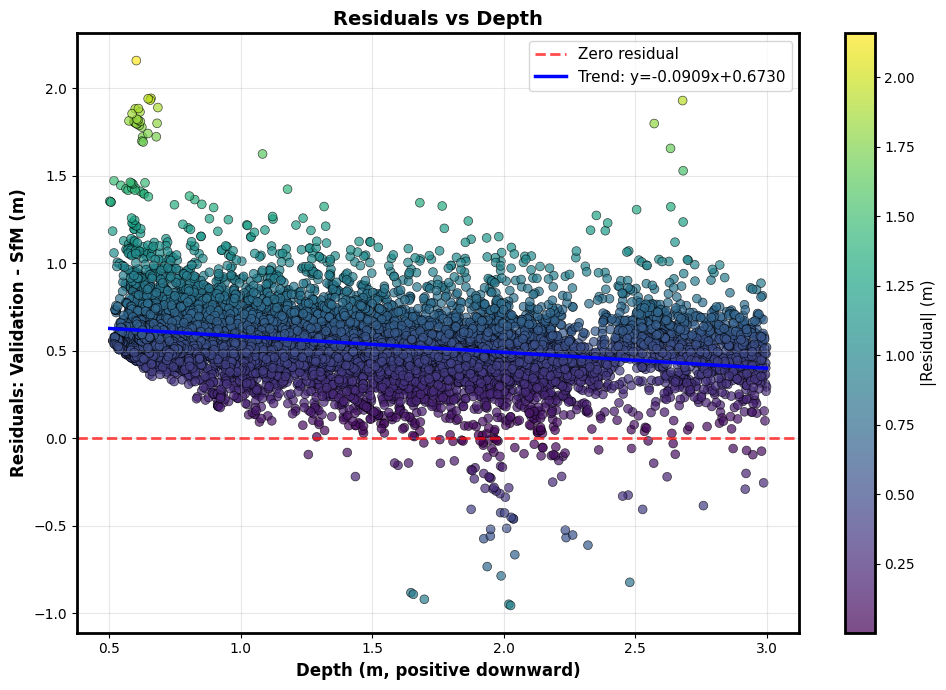

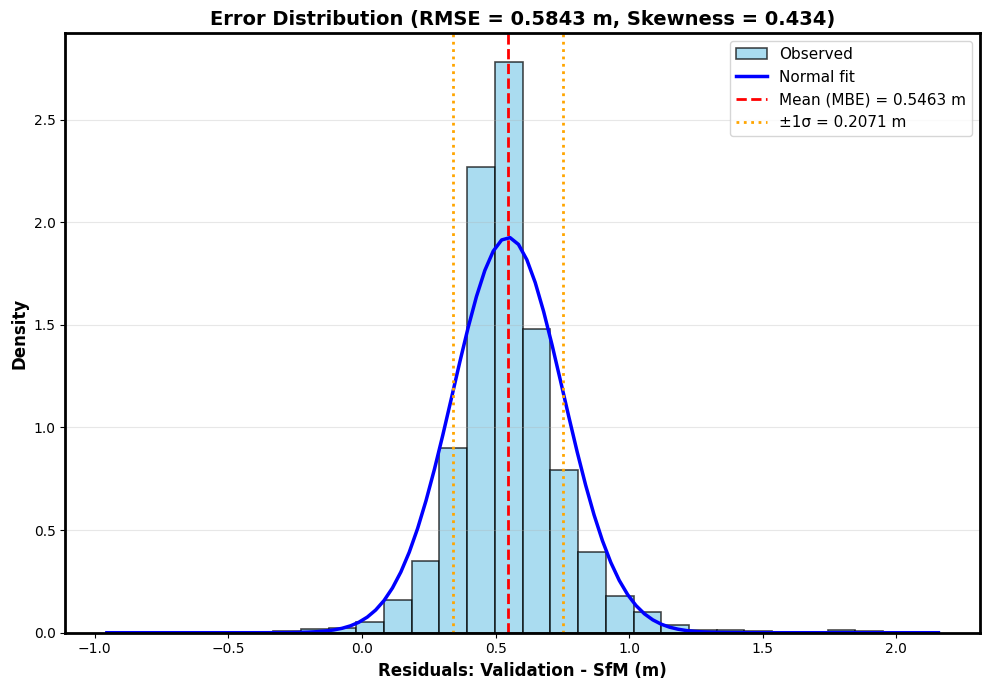

In [11]:
results = validate_bathymetry(
    pc_source= pc_corrected, validation_file= valid_dir, datum_geotiff=datum_model, pc_epsg = pc_epsg,
    min_depth= min_depth, max_depth=max_depth,                                  
    max_match_distance=10, msl_reference=0, output_dir=output_validation      
)

Export Point Cloud

In [ ]:
export_pc(pc_corrected, las, output) 